In [1]:
import torch
import numpy as np
import pandas as pd
from scipy.spatial import distance_matrix
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import seaborn as sns
from sklearn.decomposition import PCA

import pickle

In [2]:
## 读取数据
with open('data_with_phase.pickle', 'rb') as f:
    adata = pickle.load(f)
adata.shape

(5000, 7)

(array([640., 500., 426., 553., 492., 396., 433., 587., 488., 485.]),
 array([0.    , 0.0995, 0.199 , 0.2985, 0.398 , 0.4975, 0.597 , 0.6965,
        0.796 , 0.8955, 0.995 ]),
 <BarContainer object of 10 artists>)

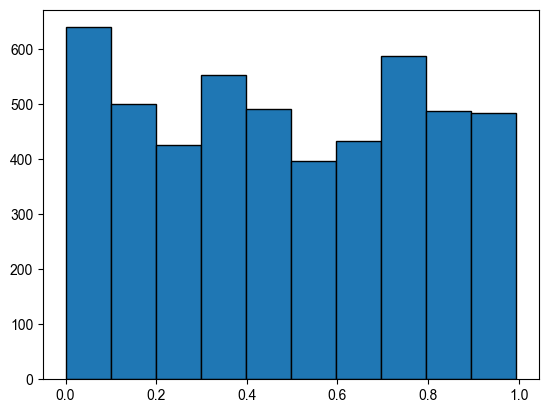

In [3]:
min = adata[:, -1].min()
max = adata[:, -1].max()
plt.hist(adata[:, -1], range=(min, max), bins=10, edgecolor='black')

In [4]:
## 按相位角划分数据
n_bins = 50
bin_labels = np.arange(n_bins)
bin_edges = np.percentile(adata[:, -1], np.linspace(0, 100, n_bins+1))

In [5]:
bin_edges

array([0.     , 0.01449, 0.0305 , 0.046  , 0.0635 , 0.07545, 0.09194,
       0.111  , 0.129  , 0.1485 , 0.1675 , 0.19178, 0.21238, 0.237  ,
       0.2635 , 0.28485, 0.30384, 0.323  , 0.34382, 0.36131, 0.3775 ,
       0.3935 , 0.41378, 0.43177, 0.45   , 0.474  , 0.495  , 0.5195 ,
       0.54144, 0.5685 , 0.595  , 0.62419, 0.646  , 0.66867, 0.6865 ,
       0.708  , 0.723  , 0.7405 , 0.7535 , 0.77161, 0.7906 , 0.80759,
       0.828  , 0.848  , 0.8695 , 0.8925 , 0.91508, 0.94006, 0.96202,
       0.98251, 0.995  ])

In [6]:
bins = pd.cut(adata[:, -1], bins=bin_edges, labels=bin_labels, include_lowest=True)
bins.value_counts()

0     100
1     102
2     102
3      97
4      99
5     100
6     101
7     100
8     101
9     102
10     96
11    100
12    101
13    105
14     94
15    100
16    102
17     98
18    100
19    101
20    102
21     97
22    100
23    101
24    101
25     99
26    102
27     97
28    101
29    100
30     99
31    103
32     97
33    101
34    103
35     97
36    104
37     95
38    100
39    100
40    100
41    101
42    100
43    102
44     99
45     98
46    100
47    100
48    100
49    100
Name: count, dtype: int64

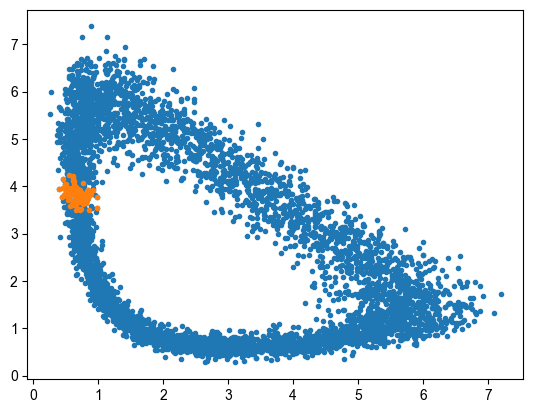

In [7]:
bdata = adata[bins == 49]
plt.scatter(adata[:, 0], adata[:, 1], marker='.')
plt.scatter(bdata[:, 0], bdata[:, 1], marker='.')

In [8]:
## 归一化细胞数据
np_data = adata[:, :-1]

# for i in range(np_data.shape[1]):
#     gene_data = np_data[:, i]
#     gene_data -= gene_data.min()
#     gene_data /= gene_data.max()
#     np_data[:, i] = gene_data
np_data.shape

(5000, 6)

In [9]:
## PCA降维
pca = PCA(n_components=2)
pca.fit(np_data)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
np_data_pca = (np_data - np.mean(np_data, axis=0)) @ V

In [10]:
## 采样数据
NN = 2000
k = 40 # 周期个数
data = np.zeros([np_data.shape[1], 40, NN])
for j in range(40):
    # 每个bin采样
    sample_indices = []
    for _ in range(k):
        for i in range(n_bins):
            bin_indices = np.where(bins == i)[0]
            if len(bin_indices) > 0:
                random_index = np.random.choice(bin_indices)
                sample_indices.append(random_index)
    data[:, j, :] = np_data[sample_indices,:].T

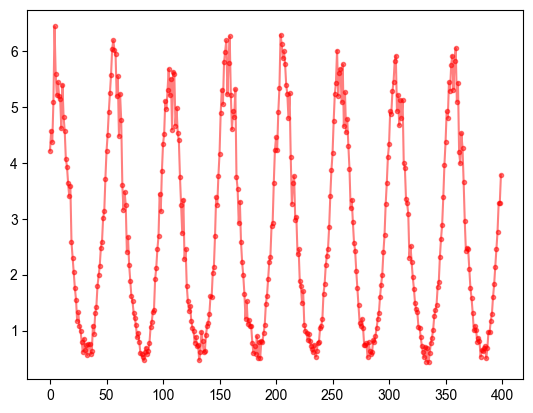

In [11]:
n = 1
fig, ax = plt.subplots()
ax.plot(range(400),data[n, 0, :400],'.-', alpha=0.5,color='red')

In [12]:
youtcome=np.zeros([78040, np_data.shape[1], 50, 1], dtype=np.float32)
for i in range(78040):
    j = i//1951
    k = i % 1951
    youtcome[i, :, :, :] = data[:, j, k:k+50].reshape(np_data.shape[1], 50, 1)

In [13]:
youtcome.shape

(78040, 6, 50, 1)

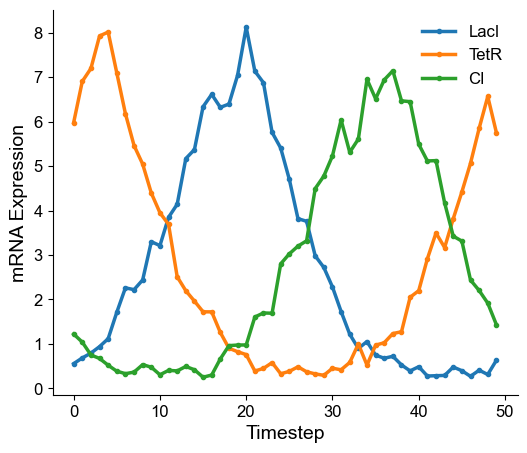

In [25]:
n = 400
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(range(50), youtcome[n, 3, :, :], '.-', linewidth=2.5, markersize=6, label='LacI', color='C0')
ax.plot(range(50), youtcome[n, 4, :, :], '.-', linewidth=2.5, markersize=6, label='TetR', color='C1')
ax.plot(range(50), youtcome[n, 5, :, :], '.-', linewidth=2.5, markersize=6, label='CI', color='C2')

ax.set_ylabel('mRNA Expression', fontsize=14)
ax.set_xlabel('Timestep', fontsize=14)
ax.tick_params(labelsize=12)

ax.legend(loc='best', fontsize=12, frameon=False)

# 去掉顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('./figures/time_series.svg', bbox_inches='tight', transparent=True)
plt.show()

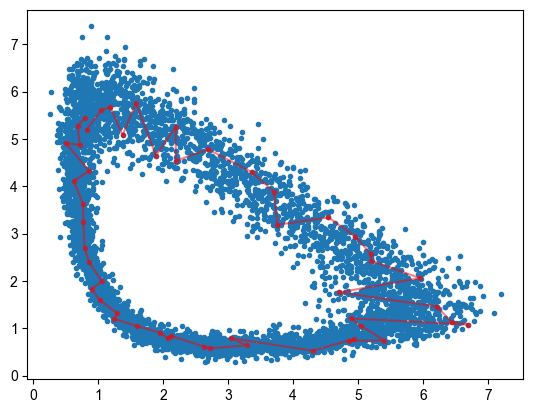

In [15]:
fig, ax = plt.subplots()
plt.scatter(adata[:, 0], adata[:, 1], marker='.')
ax.plot(youtcome[255, 0, :, :],youtcome[255, 1, :, :],'.-',alpha=0.5,color='red')

In [16]:
index = [o for o in range(youtcome.shape[0])]
np.random.shuffle(index)
ynew = youtcome[index, :, :, :]
train_data = ynew[: youtcome.shape[0] // 10 * 8, :, :, :]
val_data = ynew[youtcome.shape[0] // 10 * 8:youtcome.shape[0] // 10 * 9, :, :, :]
test_data = ynew[youtcome.shape[0] // 10 * 9:, :, :, :]

train_data = torch.tensor(train_data)
val_data = torch.tensor(val_data)
test_data = torch.tensor(test_data)

print('\n Train data size:', train_data.shape)
print('\n Val data size:' , val_data.shape)
print('\n Test data size:' , test_data.shape)
print('\n----------   Finsh generating time series data ----------')


 Train data size: torch.Size([62432, 6, 50, 1])

 Val data size: torch.Size([7804, 6, 50, 1])

 Test data size: torch.Size([7804, 6, 50, 1])

----------   Finsh generating time series data ----------


In [17]:
results = [train_data, val_data, test_data]

In [18]:
with open('data.pickle', 'wb') as f:
    pickle.dump(results, f)